In [4]:
# ============================================================
# MANIPULATION DES DONNÉES
# ============================================================
import pandas as pd
import numpy as np
import scipy.stats as ss

# ============================================================
# VISUALISATION
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# ============================================================
# SKLEARN – PREPROCESSING
# ============================================================
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV,
    GridSearchCV, cross_val_score, cross_val_predict, KFold
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    LabelEncoder, OneHotEncoder, OrdinalEncoder
)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer

# ============================================================
# SKLEARN – MODÈLES RÉGRESSION
# ============================================================
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    BaggingRegressor, AdaBoostRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

# ============================================================
# SKLEARN – MODÈLES CLASSIFICATION (pour le scoring)
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ============================================================
# SKLEARN – ÉVALUATION RÉGRESSION
# ============================================================
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error
)

# ============================================================
# SKLEARN – ÉVALUATION CLASSIFICATION / SCORING
# ============================================================
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, RocCurveDisplay, PrecisionRecallDisplay,
    precision_recall_curve, confusion_matrix
)

# ============================================================
# CALIBRATION & EXPLICABILITÉ
# ============================================================
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.inspection import permutation_importance
import shap

import warnings
warnings.filterwarnings("ignore")

set_seed = 1204
print("✅ Librairies chargées avec succès")

✅ Librairies chargées avec succès


In [5]:
df = pd.read_csv('cars_dataset.csv')


print(f"Dimensions     : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

Dimensions     : 515 lignes × 11 colonnes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   marque               515 non-null    object 
 1   annee                515 non-null    float64
 2   kilometrage          453 non-null    float64
 3   puissance_cv         469 non-null    float64
 4   nb_portes            515 non-null    int64  
 5   carburant            515 non-null    object 
 6   transmission         459 non-null    object 
 7   etat                 468 non-null    object 
 8   nb_proprietaires     457 non-null    float64
 9   consommation_L100km  454 non-null    float64
 10  prix                 515 non-null    int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 44.4+ KB


annne objet alors que ça devrait etre en int

In [7]:
df.sample(5)

,marque,annee,kilometrage,puissance_cv,nb_portes,carburant,transmission,etat,nb_proprietaires,consommation_L100km,prix
500,Volkswagen,2011.0,NaN,106.0,2,Essence,NaN,Neuf,3.0,10.3,20746
177,BMW,2005.0,144931.0,354.0,3,Hybride,Automatique,Passable,NaN,9.5,200000
460,Ford,2008.0,96122.0,195.0,4,Diesel,NaN,Mauvais,2.0,9.2,14637
108,Audi,2012.0,129948.0,NaN,2,Diesel,NaN,NaN,3.0,7.9,20072
146,Honda,2020.0,101358.0,393.0,4,Essence,Automatique,NaN,3.0,4.2,50022


In [8]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
marque,515,10,Toyota,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
annee,515.0,NaN,NaN,NaN,2013.848544,5.499237,2005.0,2009.0,2014.0,2019.0,2023.0
kilometrage,453.0,NaN,NaN,NaN,126315.856512,71694.908884,1622.0,61916.0,128377.0,187445.0,249753.0
puissance_cv,469.0,NaN,NaN,NaN,231.597015,99.458543,70.0,141.0,235.0,315.0,399.0
nb_portes,515.0,NaN,NaN,NaN,3.466019,1.117734,2.0,2.0,3.0,4.0,5.0
carburant,515,4,Électrique,145,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,459,2,Automatique,238,NaN,NaN,NaN,NaN,NaN,NaN,NaN
etat,468,5,Neuf,103,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nb_proprietaires,457.0,NaN,NaN,NaN,2.439825,1.143819,1.0,1.0,2.0,3.0,4.0
consommation_L100km,454.0,NaN,NaN,NaN,9.060793,2.760332,4.0,6.9,9.2,11.4,14.0


In [9]:
df.duplicated().sum()

np.int64(15)

                     Valeurs manquantes  Pourcentage (%)
kilometrage                          62            12.04
consommation_L100km                  61            11.84
nb_proprietaires                     58            11.26
transmission                         56            10.87
etat                                 47             9.13
puissance_cv                         46             8.93


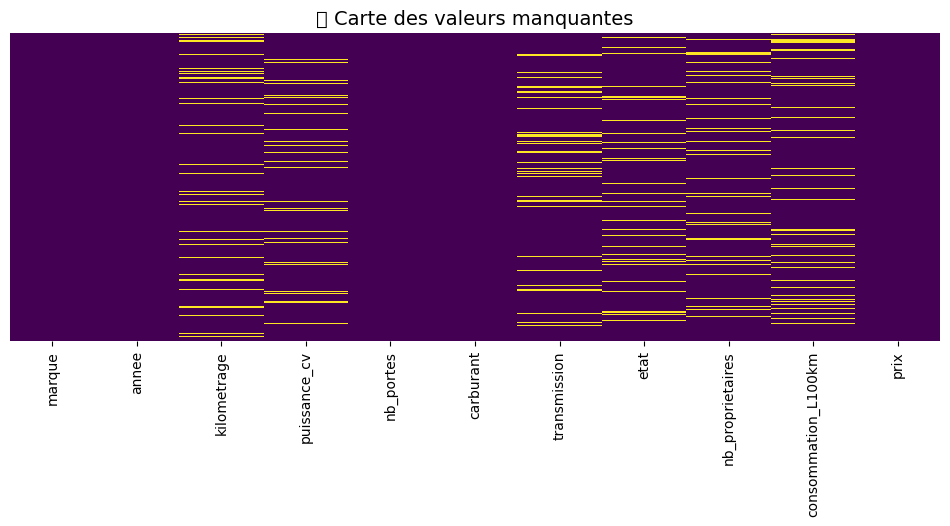

In [10]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,
    'Pourcentage (%)': missing_pct
}).query('`Valeurs manquantes` > 0')

print(missing_df)

# Heatmap des valeurs manquantes
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("🗺️ Carte des valeurs manquantes", fontsize=14)
plt.show()

Règle d'or :

< 5% → pas grave, on peut supprimer les lignes ou imputer simplement
5% - 30% → on impute (on remplace par une valeur calculée)
> 30% → la colonne est peut-être inutilisable, on la supprime

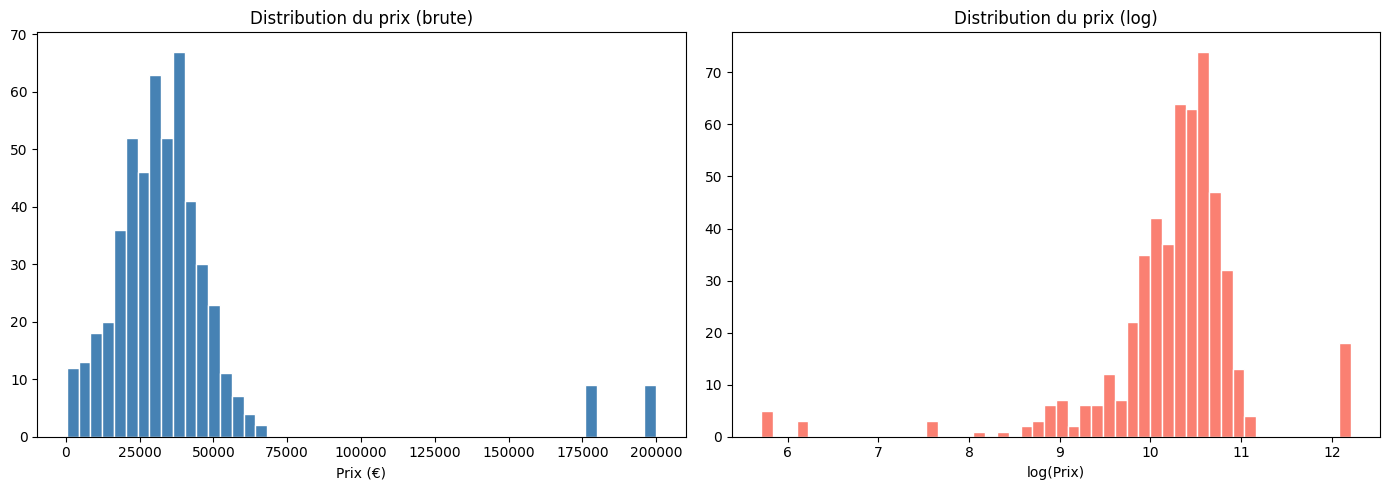

Skewness : 3.83
Kurtosis : 16.30


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution brute
axes[0].hist(df['prix'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title("Distribution du prix (brute)")
axes[0].set_xlabel("Prix (€)")

# Distribution log (utile pour la modélisation)
axes[1].hist(np.log1p(df['prix']), bins=50, color='salmon', edgecolor='white')
axes[1].set_title("Distribution du prix (log)")
axes[1].set_xlabel("log(Prix)")

plt.tight_layout()
plt.show()

print(f"Skewness : {df['prix'].skew():.2f}")
print(f"Kurtosis : {df['prix'].kurtosis():.2f}")

# Skewness = mesure l'asymétrie de la courbe
print(f"Skewness : {df['prix'].skew():.2f}")

# Kurtosis = mesure si la courbe est plate ou très pointue
print(f"Kurtosis : {df['prix'].kurtosis():.2f}")
```

### 📊 Comment interpréter les résultats ?

**La distribution brute (gauche) :**
```
         ████
        ██████
       █████████
      ████████████
█████████████████████__________  → longue queue à droite = outliers
   2k  20k  40k  60k  200k
```

> Si ta courbe ressemble à ça (queue à droite), c'est une distribution **asymétrique à droite**

**Le Skewness :**
```
Skewness ≈ 0        → distribution symétrique  ✅ idéal pour les modèles
Skewness > 1        → asymétrie forte à droite  ⚠️ problématique
Skewness < -1       → asymétrie forte à gauche  ⚠️ problématique

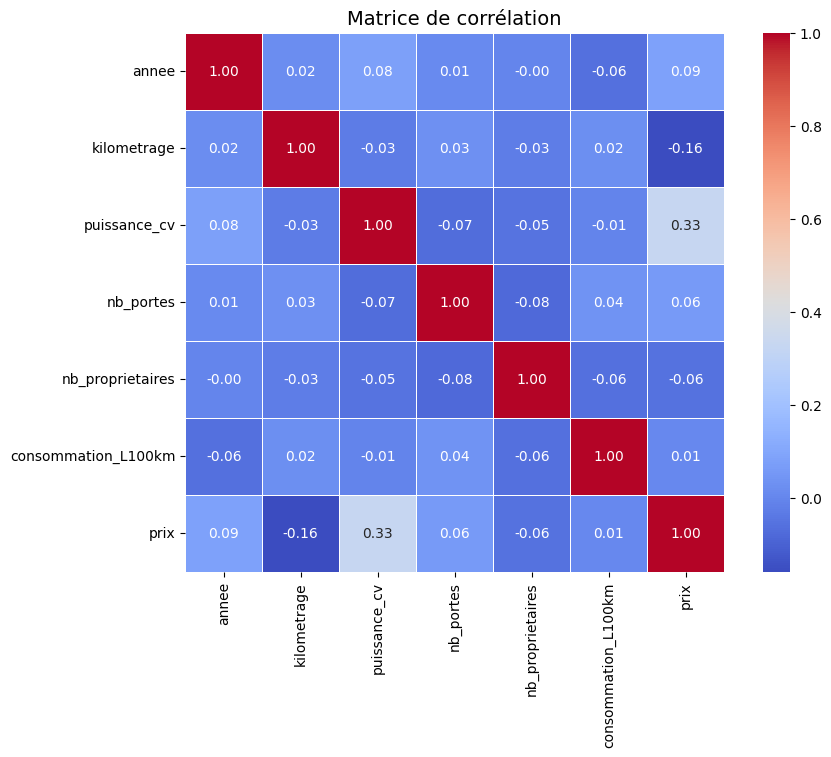

In [12]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 7))
sns.heatmap(
    df[num_cols].corr(),
    annot=True, fmt=".2f", cmap="coolwarm",
    square=True, linewidths=0.5
)
plt.title("Matrice de corrélation", fontsize=14)
plt.show()

In [13]:
#traitement des doublons
print(f"Shape avant : {df.shape}")
print(f"Nombre de doublons : {df.duplicated().sum()}")

df = df.drop_duplicates()
df = df.reset_index(drop=True)  # on remet les index proprement

print(f"Shape après : {df.shape}")

Shape avant : (515, 11)
Nombre de doublons : 15
Shape après : (500, 11)


In [14]:
#Corriger les types
# Avant correction
print("Avant :")
print(df['annee'].dtype)       # → object (string) ❌
print(df['annee'].head(10))    # tu vas voir des "2015.0" en string

# Correction
# float() d'abord car "2015.0" ne peut pas aller direct en int
df['annee'] = df['annee'].astype(float).astype(int)

# Vérification
print("\nAprès :")
print(df['annee'].dtype)       # → int64 ✅
print(df['annee'].head(10))

Avant :
float64
0    2013.0
1    2021.0
2    2021.0
3    2020.0
4    2017.0
5    2023.0
6    2021.0
7    2008.0
8    2016.0
9    2013.0
Name: annee, dtype: float64

Après :
int64
0    2013
1    2021
2    2021
3    2020
4    2017
5    2023
6    2021
7    2008
8    2016
9    2013
Name: annee, dtype: int64


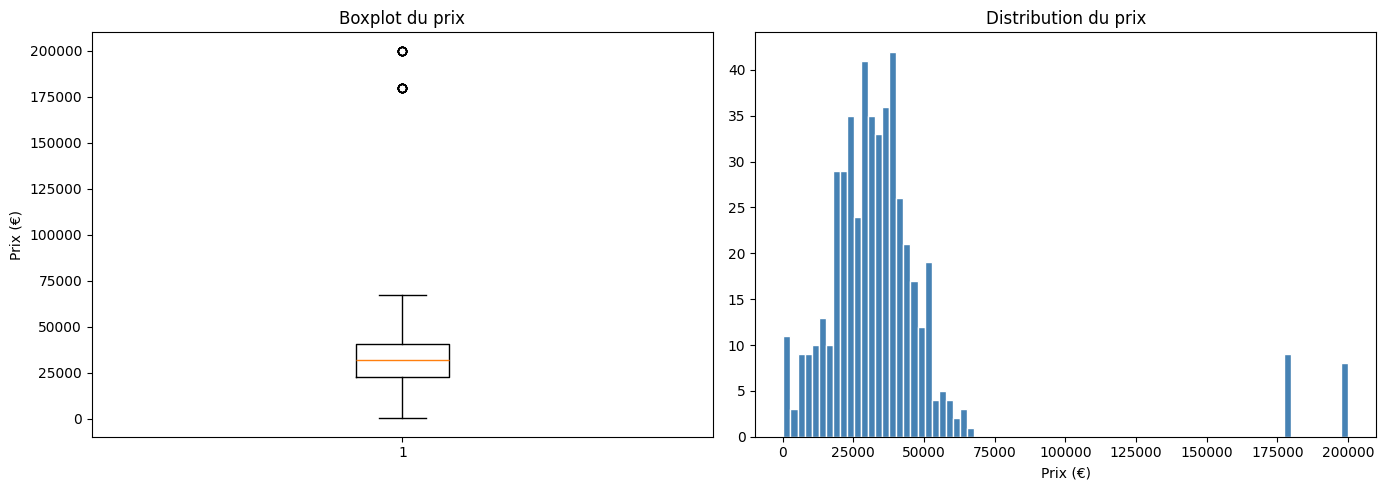

🔴 Prix les plus BAS :
[ 300  300  300  300  300  500  500  500 2000 2000]

🔴 Prix les plus HAUTS :
[180000 180000 200000 200000 200000 200000 200000 200000 200000 200000]


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot — les points au dessus/dessous des moustaches = outliers
axes[0].boxplot(df['prix'].dropna())
axes[0].set_title("Boxplot du prix")
axes[0].set_ylabel("Prix (€)")

# Les valeurs suspectes
axes[1].hist(df['prix'], bins=80, color='steelblue', edgecolor='white')
axes[1].set_title("Distribution du prix")
axes[1].set_xlabel("Prix (€)")

plt.tight_layout()
plt.show()

# On affiche les valeurs extrêmes
print("🔴 Prix les plus BAS :")
print(df['prix'].sort_values().head(10).values)

print("\n🔴 Prix les plus HAUTS :")
print(df['prix'].sort_values().tail(10).values)

In [16]:
# La méthode IQR (InterQuartile Range)
# ─────────────────────────────────────────────────────────
# Q1 = 25% des données sont en dessous
# Q3 = 75% des données sont en dessous
# IQR = Q3 - Q1  →  la "zone normale" des données
#
# Borne basse  = Q1 - 1.5 × IQR  → en dessous = outlier
# Borne haute  = Q3 + 1.5 × IQR  → au dessus  = outlier

Q1 = df['prix'].quantile(0.25)
Q3 = df['prix'].quantile(0.75)
IQR = Q3 - Q1

borne_basse = Q1 - 1.5 * IQR
borne_haute = Q3 + 1.5 * IQR

print(f"Q1           : {Q1:,.0f} €")
print(f"Q3           : {Q3:,.0f} €")
print(f"IQR          : {IQR:,.0f} €")
print(f"Borne basse  : {borne_basse:,.0f} €")
print(f"Borne haute  : {borne_haute:,.0f} €")

# Combien d'outliers ?
outliers = df[(df['prix'] < borne_basse) | (df['prix'] > borne_haute)]
print(f"\n⚠️  Nombre d'outliers détectés : {len(outliers)}")
print(outliers['prix'].values)

# Suppression
df = df[(df['prix'] >= borne_basse) & (df['prix'] <= borne_haute)]
df = df.reset_index(drop=True)

print(f"\n✅ Shape après suppression des outliers : {df.shape}")

Q1           : 22,927 €
Q3           : 40,733 €
IQR          : 17,806 €
Borne basse  : -3,782 €
Borne haute  : 67,441 €

⚠️  Nombre d'outliers détectés : 17
[180000 200000 180000 200000 180000 180000 200000 200000 180000 180000
 200000 200000 200000 180000 200000 180000 180000]

✅ Shape après suppression des outliers : (483, 11)


In [17]:
print("Valeurs manquantes restantes :")
print(df.isnull().sum()[df.isnull().sum() > 0])

Valeurs manquantes restantes :
kilometrage            57
puissance_cv           42
transmission           53
etat                   41
nb_proprietaires       55
consommation_L100km    59
dtype: int64


In [18]:
# Les colonnes numériques avec des manquants
cols_numeriques = ['kilometrage', 'puissance_cv', 'consommation_L100km', 'nb_proprietaires']

for col in cols_numeriques:
    mediane = df[col].median()
    nb_manquants = df[col].isnull().sum()
    df[col] = df[col].fillna(mediane)
    print(f"✅ {col} → {nb_manquants} valeurs remplacées par la médiane ({mediane:.1f})")

✅ kilometrage → 57 valeurs remplacées par la médiane (131079.0)
✅ puissance_cv → 42 valeurs remplacées par la médiane (233.0)
✅ consommation_L100km → 59 valeurs remplacées par la médiane (9.1)
✅ nb_proprietaires → 55 valeurs remplacées par la médiane (2.0)


In [19]:
# Les colonnes texte avec des manquants
cols_categorielles = ['transmission', 'etat']

for col in cols_categorielles:
    mode = df[col].mode()[0]   # mode()[0] = la valeur la plus fréquente
    nb_manquants = df[col].isnull().sum()
    df[col] = df[col].fillna(mode)
    print(f"✅ {col} → {nb_manquants} valeurs remplacées par le mode ('{mode}')")

✅ transmission → 53 valeurs remplacées par le mode ('Automatique')
✅ etat → 41 valeurs remplacées par le mode ('Neuf')


In [20]:
print("\n🔍 Vérification — valeurs manquantes restantes :")
total_manquants = df.isnull().sum().sum()
print(df.isnull().sum())
print(f"\n✅ Total manquants restants : {total_manquants}")


🔍 Vérification — valeurs manquantes restantes :
marque                 0
annee                  0
kilometrage            0
puissance_cv           0
nb_portes              0
carburant              0
transmission           0
etat                   0
nb_proprietaires       0
consommation_L100km    0
prix                   0
dtype: int64

✅ Total manquants restants : 0


In [21]:
#Encodage
# Manuelle → 0  /  Automatique → 1
le = LabelEncoder()
df['transmission'] = le.fit_transform(df['transmission'])

print("transmission :")
print(df['transmission'].value_counts())

transmission :
transmission
0    276
1    207
Name: count, dtype: int64


In [22]:
# On définit l'ordre NOUS MÊMES car Mauvais < Passable < Bon < Très bon < Neuf
ordre_etat = [['Mauvais', 'Passable', 'Bon', 'Très bon', 'Neuf']]

oe = OrdinalEncoder(categories=ordre_etat)
df['etat'] = oe.fit_transform(df[['etat']])

# Résultat :
# Mauvais → 0  /  Passable → 1  /  Bon → 2  /  Très bon → 3  /  Neuf → 4

print("etat :")
print(df['etat'].value_counts().sort_index())

etat :
etat
0.0     93
1.0     87
2.0     94
3.0     73
4.0    136
Name: count, dtype: int64


In [23]:
# drop_first=True → on supprime une colonne par variable
# pour éviter la redondance (si pas Toyota, BMW, Renault... → forcément la dernière)
df = pd.get_dummies(df, columns=['marque', 'carburant'], drop_first=True)

print(f"\n✅ Shape après encodage : {df.shape}")
print(f"Nouvelles colonnes : {list(df.columns)}")


✅ Shape après encodage : (483, 21)
Nouvelles colonnes : ['annee', 'kilometrage', 'puissance_cv', 'nb_portes', 'transmission', 'etat', 'nb_proprietaires', 'consommation_L100km', 'prix', 'marque_BMW', 'marque_Ford', 'marque_Honda', 'marque_Mercedes', 'marque_Nissan', 'marque_Peugeot', 'marque_Renault', 'marque_Toyota', 'marque_Volkswagen', 'carburant_Essence', 'carburant_Hybride', 'carburant_Électrique']


🧠 Pourquoi pas la même méthode pour tous ?
❌ Le piège du Label Encoding sur du nominal
python# Si on fait Label Encoding sur marque :
# Toyota → 0  /  BMW → 1  /  Mercedes → 2

# Le modèle va CROIRE que :
# Mercedes (2) > BMW (1) > Toyota (0)
# Donc Mercedes vaut "2 fois plus" que BMW  ← FAUX ❌
# Les marques n'ont pas d'ordre logique !
✅ One-Hot Encoding sur du nominal
python# On crée UNE colonne par marque avec 0 ou 1 :
#
#   marque_BMW  marque_Mercedes  marque_Toyota ...
#       0             1               0         ← cette voiture est une Mercedes
#       1             0               0         ← cette voiture est une BMW
#
# Aucun ordre implicite → le modèle traite chaque marque indépendamment ✅
✅ Ordinal Encoding sur de l'ordinal
python# etat a un ordre logique qui existe vraiment :
# Mauvais(0) < Passable(1) < Bon(2) < Très bon(3) < Neuf(4)
#
# Le modèle peut utiliser cet ordre → Neuf(4) prédit un prix plus élevé ✅
# C'est une vraie information qu'on lui donne

In [24]:
print("Aperçu du dataset encodé :")
print(df.head())
print(f"\nShape final : {df.shape}")
print(f"\nTypes des colonnes :")
print(df.dtypes)

Aperçu du dataset encodé :
   annee  kilometrage  puissance_cv  nb_portes  transmission  etat  \
0   2013     178595.0         374.0          2             0   2.0   
1   2021     124085.0         209.0          5             0   1.0   
2   2020      19256.0         362.0          2             1   0.0   
3   2017     232448.0         130.0          2             1   1.0   
4   2023     100158.0         267.0          2             1   4.0   

   nb_proprietaires  consommation_L100km   prix  marque_BMW  ...  \
0               4.0                  9.6  35837       False  ...   
1               3.0                  8.3  22458       False  ...   
2               1.0                 12.4  38532       False  ...   
3               3.0                  5.4   5307       False  ...   
4               3.0                  8.3  45472       False  ...   

   marque_Honda  marque_Mercedes  marque_Nissan  marque_Peugeot  \
0         False            False          False           False   
1        

In [25]:
df.sample(5)

,annee,kilometrage,puissance_cv,nb_portes,transmission,etat,nb_proprietaires,consommation_L100km,prix,marque_BMW,...,marque_Honda,marque_Mercedes,marque_Nissan,marque_Peugeot,marque_Renault,marque_Toyota,marque_Volkswagen,carburant_Essence,carburant_Hybride,carburant_Électrique
460,2019,105373.0,214.0,3,1,2.0,1.0,9.1,28552,False,...,True,False,False,False,False,False,False,True,False,False
114,2020,126944.0,233.0,4,0,0.0,2.0,11.1,19984,False,...,True,False,False,False,False,False,False,False,False,True
381,2009,139892.0,370.0,2,1,3.0,3.0,10.8,43379,False,...,False,False,False,False,False,True,False,False,False,True
68,2012,206592.0,245.0,2,0,2.0,4.0,9.2,34299,True,...,False,False,False,False,False,False,False,True,False,False
223,2007,51693.0,235.0,2,1,2.0,1.0,11.4,27947,False,...,False,False,False,False,True,False,False,False,False,True


In [26]:
#Feature Engineering
# Plutôt que l'année brute (2015, 2018...)
# le modèle comprend mieux "cette voiture a 9 ans"
df['age_vehicule'] = 2024 - df['annee']

print(df[['annee', 'age_vehicule']].head(5))

   annee  age_vehicule
0   2013            11
1   2021             3
2   2020             4
3   2017             7
4   2023             1


In [27]:
# Une voiture avec 100 000 km en 10 ans = normale
# Une voiture avec 100 000 km en 2 ans  = très usée
# L'année seule ou le km seul ne capture pas ça

df['km_par_an'] = df['kilometrage'] / (df['age_vehicule'] + 1)
# +1 pour éviter la division par zéro si age = 0

print(df[['kilometrage', 'age_vehicule', 'km_par_an']].head(5))

   kilometrage  age_vehicule     km_par_an
0     178595.0            11  14882.916667
1     124085.0             3  31021.250000
2      19256.0             4   3851.200000
3     232448.0             7  29056.000000
4     100158.0             1  50079.000000


In [28]:
# Combine puissance et consommation en un seul indicateur
# Une voiture puissante MAIS économe = grande valeur

df['puissance_par_litre'] = df['puissance_cv'] / df['consommation_L100km']

print(df[['puissance_cv', 'consommation_L100km', 'puissance_par_litre']].head(5))

   puissance_cv  consommation_L100km  puissance_par_litre
0         374.0                  9.6            38.958333
1         209.0                  8.3            25.180723
2         362.0                 12.4            29.193548
3         130.0                  5.4            24.074074
4         267.0                  8.3            32.168675


In [29]:
# Variable 0/1 simple : la voiture a moins de 5 ans ?
# Certains modèles captent mieux les seuils via une variable binaire

df['est_recente'] = (df['age_vehicule'] <= 5).astype(int)

print(df['est_recente'].value_counts())

est_recente
0    357
1    126
Name: count, dtype: int64


In [30]:
# age_vehicule et km_par_an capturent déjà toute l'info de annee
# La garder créerait de la multicolinéarité

df.drop(columns=['annee'], inplace=True)

print(f"\n✅ Shape après Feature Engineering : {df.shape}")
print(f"Colonnes : {list(df.columns)}")


✅ Shape après Feature Engineering : (483, 24)
Colonnes : ['kilometrage', 'puissance_cv', 'nb_portes', 'transmission', 'etat', 'nb_proprietaires', 'consommation_L100km', 'prix', 'marque_BMW', 'marque_Ford', 'marque_Honda', 'marque_Mercedes', 'marque_Nissan', 'marque_Peugeot', 'marque_Renault', 'marque_Toyota', 'marque_Volkswagen', 'carburant_Essence', 'carburant_Hybride', 'carburant_Électrique', 'age_vehicule', 'km_par_an', 'puissance_par_litre', 'est_recente']


In [31]:
# On vérifie les corrélations des nouvelles variables avec le prix
nouvelles_features = ['age_vehicule', 'km_par_an', 'puissance_par_litre', 'est_recente']

print("📊 Corrélations des nouvelles features avec prix :")
for col in nouvelles_features:
    corr = df[col].corr(df['prix'])
    print(f"  {col:25s} →  {corr:.3f}")

📊 Corrélations des nouvelles features avec prix :
  age_vehicule              →  -0.166
  km_par_an                 →  0.010
  puissance_par_litre       →  0.441
  est_recente               →  0.111


In [32]:
df.drop(columns=['km_par_an'], inplace=True)
print(f"✅ Shape final : {df.shape}")

✅ Shape final : (483, 23)


In [33]:
# Corrélations de TOUTES les variables numériques avec prix
corr_prix = df.select_dtypes(include=np.number).corr()['prix'].drop('prix')
corr_prix = corr_prix.abs().sort_values(ascending=False)

print("📊 Toutes les features classées par corrélation avec prix :")
print(corr_prix.round(3))

📊 Toutes les features classées par corrélation avec prix :
puissance_cv           0.582
puissance_par_litre    0.441
etat                   0.372
kilometrage            0.221
age_vehicule           0.166
est_recente            0.111
nb_proprietaires       0.068
transmission           0.048
consommation_L100km    0.021
nb_portes              0.007
Name: prix, dtype: float64


Feature                Corrélation    Verdict
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
puissance_cv           0.582   ✅  Top feature
puissance_par_litre    0.441   ✅  Notre feature engineerée 💪
etat                   0.372   ✅  L'état de la voiture compte
kilometrage            0.221   🟡  Attendu plus élevé mais ok
age_vehicule           0.166   🟡  Utile en complément
est_recente            0.111   🟡  On garde
nb_proprietaires       0.068   ❌  Quasi inutile
transmission           0.048   ❌  Quasi inutile
consommation_L100km    0.021   ❌  Inutile
nb_portes              0.007   ❌  Inutile

In [34]:
# Corrélation < 0.05 → elles n'apportent rien au modèle
# et rajoutent du bruit

cols_a_supprimer = ['nb_proprietaires', 'transmission',
                    'consommation_L100km', 'nb_portes']

df.drop(columns=cols_a_supprimer, inplace=True)

print(f"✅ Shape après suppression : {df.shape}")
print(f"Features restantes : {list(df.columns)}")

✅ Shape après suppression : (483, 19)
Features restantes : ['kilometrage', 'puissance_cv', 'etat', 'prix', 'marque_BMW', 'marque_Ford', 'marque_Honda', 'marque_Mercedes', 'marque_Nissan', 'marque_Peugeot', 'marque_Renault', 'marque_Toyota', 'marque_Volkswagen', 'carburant_Essence', 'carburant_Hybride', 'carburant_Électrique', 'age_vehicule', 'puissance_par_litre', 'est_recente']


---

# ⚖️ Étape 2.7 — Normalisation

## D'abord, pourquoi normaliser ?
```
Sans normalisation :
kilometrage    →  valeurs entre 0 et 250 000
puissance_cv   →  valeurs entre 70 et 400
etat           →  valeurs entre 0 et 4

Le modèle va croire que kilometrage est 600x plus important
que etat juste parce que ses chiffres sont plus grands ❌
```

## Les 3 méthodes qui existent :
```
StandardScaler   →  moyenne=0, écart-type=1
                    formule : (x - moyenne) / écart-type
                    ✅ idéal si distribution normale

MinMaxScaler     →  ramène tout entre 0 et 1
                    formule : (x - min) / (max - min)
                    ❌ sensible aux outliers résiduels

RobustScaler     →  utilise la médiane et l'IQR
                    formule : (x - médiane) / IQR
                    ✅ idéal si outliers résiduels (notre cas)

In [35]:
# Les colonnes One-Hot (0/1) n'ont PAS besoin d'être normalisées
# Elles sont déjà dans la bonne échelle

# On identifie les colonnes à normaliser
cols_onehot = [col for col in df.columns if col.startswith('marque_')
                                          or col.startswith('carburant_')]

cols_binaires = ['est_recente']  # déjà en 0/1

# Tout ce qui reste (sauf prix et les binaires) → à normaliser
cols_a_normaliser = [col for col in df.columns
                     if col not in cols_onehot + cols_binaires + ['prix']]

print(f"Colonnes à normaliser : {cols_a_normaliser}")

# On applique RobustScaler
scaler = RobustScaler()
df[cols_a_normaliser] = scaler.fit_transform(df[cols_a_normaliser])

print("\nAperçu après normalisation :")
print(df[cols_a_normaliser].describe().round(2))

Colonnes à normaliser : ['kilometrage', 'puissance_cv', 'etat', 'age_vehicule', 'puissance_par_litre']

Aperçu après normalisation :
       kilometrage  puissance_cv    etat  age_vehicule  puissance_par_litre
count       483.00        483.00  483.00        483.00               483.00
mean         -0.03         -0.01    0.05          0.02                 0.16
std           0.62          0.59    0.50          0.55                 0.93
min          -1.19         -1.03   -0.67         -0.90                -1.12
25%          -0.53         -0.53   -0.33         -0.50                -0.49
50%           0.00          0.00    0.00          0.00                 0.00
75%           0.47          0.47    0.67          0.50                 0.51
max           1.09          1.04    0.67          0.90                 3.93


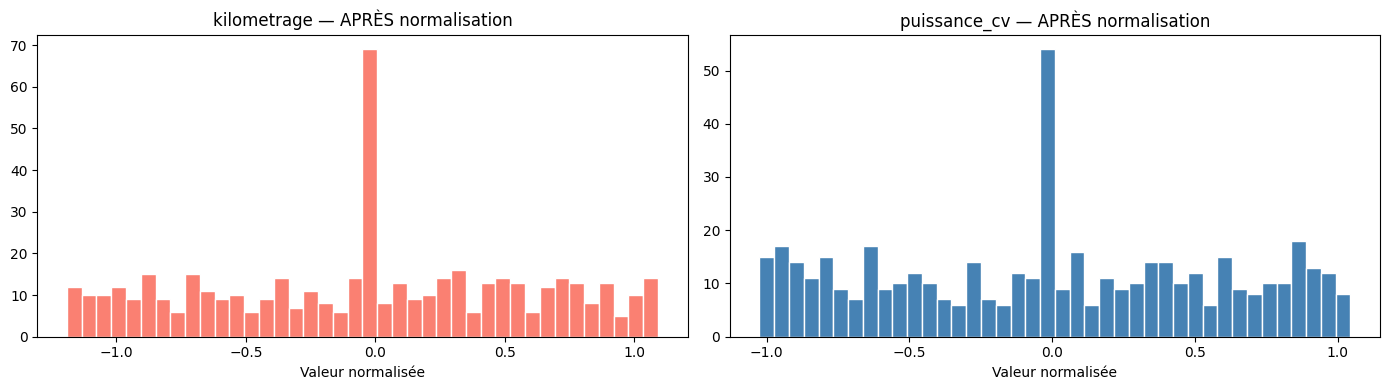


✅ Dataset final prêt pour la modélisation
Shape : (483, 19)


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Avant (kilometrage original — on garde une copie pour montrer)
axes[0].hist(df['kilometrage'], bins=40, color='salmon', edgecolor='white')
axes[0].set_title("kilometrage — APRÈS normalisation")
axes[0].set_xlabel("Valeur normalisée")

axes[1].hist(df['puissance_cv'], bins=40, color='steelblue', edgecolor='white')
axes[1].set_title("puissance_cv — APRÈS normalisation")
axes[1].set_xlabel("Valeur normalisée")

plt.tight_layout()
plt.show()

print(f"\n✅ Dataset final prêt pour la modélisation")
print(f"Shape : {df.shape}")


```

---

## 🏁 Bilan complet de la Phase 2
```
✅ Doublons supprimés        : 15
✅ Outliers supprimés        : 17
✅ Types corrigés            : annee string → int
✅ Valeurs manquantes        : imputées (médiane + mode)
✅ Encodage                  : OrdinalEncoder, LabelEncoder, OneHotEncoder
✅ Feature Engineering       : 3 nouvelles variables créées
✅ Features inutiles         : 4 supprimées
✅ Normalisation             : RobustScaler appliqué

In [37]:
# On sépare les features (X) de la cible (y)
X = df.drop(columns=['prix'])
y = df['prix']

# 80% pour entraîner / 20% pour tester
# random_state = résultats reproductibles
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=set_seed
)

print(f"✅ X_train : {X_train.shape}")
print(f"✅ X_test  : {X_test.shape}")
print(f"✅ y_train : {y_train.shape}")
print(f"✅ y_test  : {y_test.shape}")

✅ X_train : (386, 18)
✅ X_test  : (97, 18)
✅ y_train : (386,)
✅ y_test  : (97,)


In [38]:
# On crée cette fonction qu'on réutilisera pour TOUS les modèles
def evaluer_modele(nom, modele, X_train, X_test, y_train, y_test):

    # Prédictions
    y_pred_train = modele.predict(X_train)
    y_pred_test  = modele.predict(X_test)

    # Métriques
    # MAE  = erreur moyenne en €  (facile à interpréter)
    # RMSE = pénalise les grosses erreurs
    # R²   = % de variance expliquée (1.0 = parfait / 0 = nul)

    mae  = mean_absolute_error(y_test, y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)
    r2_train = r2_score(y_train, y_pred_train)

    print(f"\n{'━'*45}")
    print(f"  📊 {nom}")
    print(f"{'━'*45}")
    print(f"  MAE       : {mae:>10,.0f} €")
    print(f"  RMSE      : {rmse:>10,.0f} €")
    print(f"  R² Test   : {r2:>10.4f}")
    print(f"  R² Train  : {r2_train:>10.4f}")

    # Détection overfitting
    diff = r2_train - r2
    if diff > 0.1:
        print(f"  ⚠️  Overfitting détecté  (écart: {diff:.3f})")
    else:
        print(f"  ✅ Pas d'overfitting     (écart: {diff:.3f})")

    return {
        'Modèle': nom,
        'MAE': round(mae, 0),
        'RMSE': round(rmse, 0),
        'R² Test': round(r2, 4),
        'R² Train': round(r2_train, 4)
    }

# Tableau qui stockera les résultats de tous les modèles
resultats = []
print("✅ Fonction d'évaluation prête")

✅ Fonction d'évaluation prête


---

## 3️⃣ Les métriques expliquées
```
MAE  (Mean Absolute Error)
→ Erreur moyenne en valeur absolue
→ "En moyenne le modèle se trompe de X €"
→ MAE = 3 000€ → les prédictions sont à ±3 000€ du vrai prix

RMSE (Root Mean Squared Error)  
→ Comme MAE mais pénalise les GROSSES erreurs
→ Toujours > MAE
→ Si RMSE >> MAE → il y a des erreurs très importantes sur certaines voitures

R²   (R-squared)  
→ % de la variance du prix expliqué par le modèle
→ R² = 0.85 → le modèle explique 85% des variations de prix
→ R² = 1.00 → prédiction parfaite ✅
→ R² = 0.00 → le modèle ne prédit rien ❌
→ R² < 0.00 → pire qu'une prédiction aléatoire 💀

R² Train vs R² Test
→ R²Train = 0.95 / R²Test = 0.60 → OVERFITTING ⚠️
→ R²Train = 0.82 / R²Test = 0.80 → PARFAIT ✅

In [39]:
# Le plus simple — relation linéaire entre features et prix
# prix = a×puissance + b×kilometrage + c×etat + ... + constante

lr = LinearRegression()
lr.fit(X_train, y_train)

res_lr = evaluer_modele("Régression Linéaire", lr,
                         X_train, X_test, y_train, y_test)
resultats.append(res_lr)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📊 Régression Linéaire
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MAE       :      4,491 €
  RMSE      :      7,585 €
  R² Test   :     0.6794
  R² Train  :     0.7597
  ✅ Pas d'overfitting     (écart: 0.080)


In [40]:
# Comme la régression linéaire MAIS elle pénalise les gros coefficients
# Utile quand certaines features sont corrélées entre elles
# alpha = force de la pénalité (+ grand = + régularisé)

ridge = Ridge(alpha=10)
ridge.fit(X_train, y_train)

res_ridge = evaluer_modele("Ridge (L2)", ridge,
                            X_train, X_test, y_train, y_test)
resultats.append(res_ridge)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📊 Ridge (L2)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MAE       :      5,009 €
  RMSE      :      7,924 €
  R² Test   :     0.6500
  R² Train  :     0.7471
  ✅ Pas d'overfitting     (écart: 0.097)


In [41]:
# Comme Ridge MAIS peut mettre des coefficients à EXACTEMENT 0
# → Fait une sélection automatique de features
# Les features peu importantes → coefficient = 0 → supprimées

lasso = Lasso(alpha=10)
lasso.fit(X_train, y_train)

res_lasso = evaluer_modele("Lasso (L1)", lasso,
                            X_train, X_test, y_train, y_test)
resultats.append(res_lasso)

# Quelles features Lasso a-t-il gardées ?
coefs = pd.Series(lasso.coef_, index=X.columns)
print("\n🔍 Features gardées par Lasso (coef ≠ 0) :")
print(coefs[coefs != 0].sort_values(ascending=False))


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📊 Lasso (L1)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MAE       :      4,575 €
  RMSE      :      7,638 €
  R² Test   :     0.6748
  R² Train  :     0.7594
  ✅ Pas d'overfitting     (écart: 0.085)

🔍 Features gardées par Lasso (coef ≠ 0) :
puissance_cv            11589.160064
etat                     8479.648362
marque_Mercedes          8325.495474
carburant_Électrique     5450.586136
marque_BMW               4149.719468
est_recente               739.775698
carburant_Hybride         694.243677
puissance_par_litre       522.915398
marque_Volkswagen       -1821.056702
carburant_Essence       -2907.285058
age_vehicule            -3657.902833
kilometrage             -4135.592432
marque_Toyota           -4249.931392
marque_Nissan           -4572.576155
marque_Honda            -4725.622416
marque_Peugeot          -5842.798204
marque_Ford             -6172.477537
marque_Renault          -8898.202199
dtype: float64


In [42]:
# Crée des règles de décision type :
# SI puissance > 150 ET kilometrage < 50000 ALORS prix = 35 000€

dt = DecisionTreeRegressor(max_depth=6, random_state=set_seed)
dt.fit(X_train, y_train)

res_dt = evaluer_modele("Decision Tree", dt,
                         X_train, X_test, y_train, y_test)
resultats.append(res_dt)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📊 Decision Tree
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MAE       :      8,026 €
  RMSE      :     10,853 €
  R² Test   :     0.3435
  R² Train  :     0.7589
  ⚠️  Overfitting détecté  (écart: 0.415)


In [43]:
# Construit 100 Decision Trees différents
# Chaque arbre vote → on prend la moyenne des votes
# Beaucoup moins d'overfitting qu'un seul arbre

rf = RandomForestRegressor(n_estimators=100,
                            max_depth=10,
                            random_state=set_seed)
rf.fit(X_train, y_train)

res_rf = evaluer_modele("Random Forest", rf,
                         X_train, X_test, y_train, y_test)
resultats.append(res_rf)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📊 Random Forest
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MAE       :      6,096 €
  RMSE      :      9,136 €
  R² Test   :     0.5348
  R² Train  :     0.9307
  ⚠️  Overfitting détecté  (écart: 0.396)


In [44]:
# Construit les arbres UN PAR UN
# Chaque arbre corrige les erreurs du précédent
# Généralement le plus performant sur des données tabulaires

xgb = XGBRegressor(n_estimators=200,
                   learning_rate=0.05,
                   max_depth=6,
                   random_state=set_seed,
                   verbosity=0)
xgb.fit(X_train, y_train)

res_xgb = evaluer_modele("XGBoost", xgb,
                          X_train, X_test, y_train, y_test)
resultats.append(res_xgb)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📊 XGBoost
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MAE       :      5,996 €
  RMSE      :      9,250 €
  R² Test   :     0.5232
  R² Train  :     0.9902
  ⚠️  Overfitting détecté  (écart: 0.467)


In [45]:
# Trouve les K voitures les plus similaires dans le train
# et fait la moyenne de leurs prix

knn = KNeighborsRegressor(n_neighbors=7)
knn.fit(X_train, y_train)

res_knn = evaluer_modele("KNN Regressor", knn,
                          X_train, X_test, y_train, y_test)
resultats.append(res_knn)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📊 KNN Regressor
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MAE       :      7,268 €
  RMSE      :      9,446 €
  R² Test   :     0.5027
  R² Train  :     0.6491
  ⚠️  Overfitting détecté  (écart: 0.146)



🏆 CLASSEMENT FINAL DES MODÈLES
             Modèle    MAE    RMSE  R² Test  R² Train
Régression Linéaire 4491.0  7585.0   0.6794    0.7597
         Lasso (L1) 4575.0  7638.0   0.6748    0.7594
         Ridge (L2) 5009.0  7924.0   0.6500    0.7471
      Random Forest 6096.0  9136.0   0.5348    0.9307
            XGBoost 5996.0  9250.0   0.5232    0.9902
      KNN Regressor 7268.0  9446.0   0.5027    0.6491
      Decision Tree 8026.0 10853.0   0.3435    0.7589


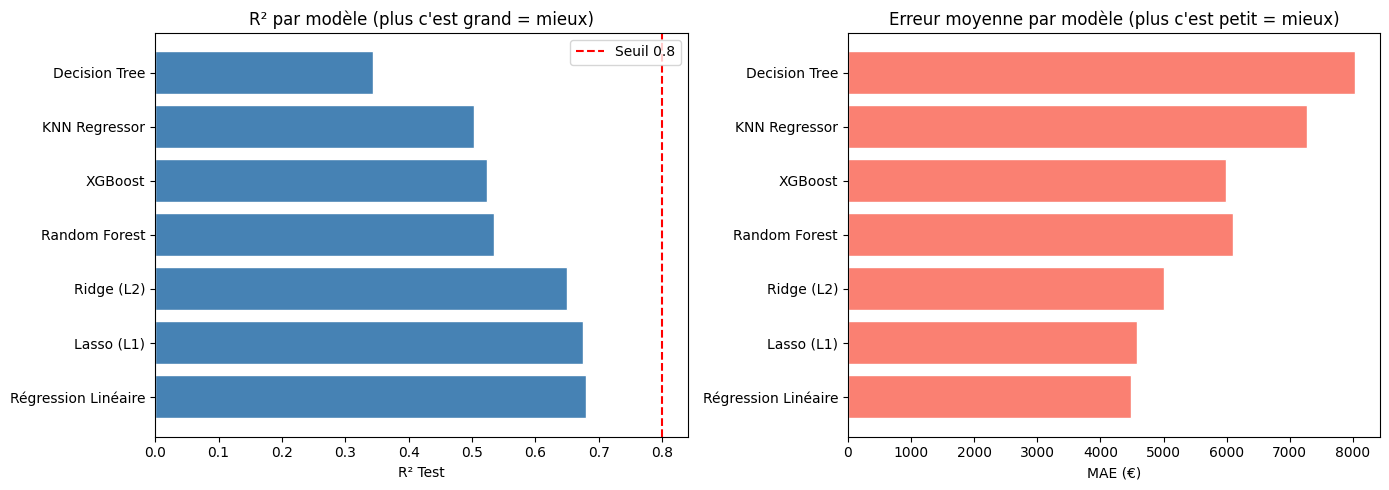

In [46]:
df_resultats = pd.DataFrame(resultats)
df_resultats = df_resultats.sort_values('R² Test', ascending=False)
df_resultats = df_resultats.reset_index(drop=True)

print("\n🏆 CLASSEMENT FINAL DES MODÈLES")
print(df_resultats.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² par modèle
axes[0].barh(df_resultats['Modèle'], df_resultats['R² Test'],
             color='steelblue', edgecolor='white')
axes[0].set_xlabel('R² Test')
axes[0].set_title('R² par modèle (plus c\'est grand = mieux)')
axes[0].axvline(x=0.8, color='red', linestyle='--', label='Seuil 0.8')
axes[0].legend()

# MAE par modèle
axes[1].barh(df_resultats['Modèle'], df_resultats['MAE'],
             color='salmon', edgecolor='white')
axes[1].set_xlabel('MAE (€)')
axes[1].set_title('Erreur moyenne par modèle (plus c\'est petit = mieux)')

plt.tight_layout()
plt.show()

In [47]:
param_rf = {
    'n_estimators'      : [50, 100, 200, 300],
    'max_depth'         : [3, 4, 5, 6, 8],      # ← on limite la profondeur
    'min_samples_split' : [10, 20, 30, 50],      # ← min lignes pour splitter
    'min_samples_leaf'  : [5, 10, 20],           # ← min lignes dans une feuille
    'max_features'      : ['sqrt', 0.5, 0.7]     # ← nb features utilisées
}

search_rf = RandomizedSearchCV(
    estimator   = RandomForestRegressor(random_state=set_seed),
    param_distributions = param_rf,
    n_iter      = 30,        # on teste 30 combinaisons aléatoires
    cv          = 5,         # 5-fold cross validation
    scoring     = 'r2',
    n_jobs      = -1,        # utilise tous les CPU disponibles
    random_state= set_seed,
    verbose     = 1
)

search_rf.fit(X_train, y_train)

print(f"\n✅ Meilleurs paramètres Random Forest :")
print(search_rf.best_params_)

# On évalue le meilleur modèle trouvé
best_rf = search_rf.best_estimator_
res_best_rf = evaluer_modele("Random Forest (Tuné)", best_rf,
                              X_train, X_test, y_train, y_test)
resultats.append(res_best_rf)

Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Meilleurs paramètres Random Forest :
{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 0.5, 'max_depth': 8}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📊 Random Forest (Tuné)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MAE       :      6,651 €
  RMSE      :      9,500 €
  R² Test   :     0.4970
  R² Train  :     0.7653
  ⚠️  Overfitting détecté  (écart: 0.268)


In [48]:
param_xgb = {
    'n_estimators'  : [50, 100, 200, 300],
    'max_depth'     : [2, 3, 4, 5],          # ← arbres moins profonds
    'learning_rate' : [0.01, 0.05, 0.1],     # ← apprend plus lentement
    'subsample'     : [0.6, 0.7, 0.8],       # ← utilise X% des lignes
    'colsample_bytree': [0.6, 0.7, 0.8],     # ← utilise X% des features
    'reg_alpha'     : [0, 0.1, 1, 5],        # ← régularisation L1
    'reg_lambda'    : [1, 5, 10, 20]         # ← régularisation L2
}

search_xgb = RandomizedSearchCV(
    estimator   = XGBRegressor(random_state=set_seed, verbosity=0),
    param_distributions = param_xgb,
    n_iter      = 30,
    cv          = 5,
    scoring     = 'r2',
    n_jobs      = -1,
    random_state= set_seed,
    verbose     = 1
)

search_xgb.fit(X_train, y_train)

print(f"\n✅ Meilleurs paramètres XGBoost :")
print(search_xgb.best_params_)

best_xgb = search_xgb.best_estimator_
res_best_xgb = evaluer_modele("XGBoost (Tuné)", best_xgb,
                               X_train, X_test, y_train, y_test)
resultats.append(res_best_xgb)

Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Meilleurs paramètres XGBoost :
{'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 0.1, 'n_estimators': 200, 'max_depth': 2, 'learning_rate': 0.1, 'colsample_bytree': 0.6}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📊 XGBoost (Tuné)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MAE       :      5,660 €
  RMSE      :      8,777 €
  R² Test   :     0.5706
  R² Train  :     0.8266
  ⚠️  Overfitting détecté  (écart: 0.256)


In [49]:
df_resultats = pd.DataFrame(resultats)
df_resultats = df_resultats.sort_values('R² Test', ascending=False)
df_resultats = df_resultats.reset_index(drop=True)

print("\n🏆 CLASSEMENT FINAL AVEC TUNING")
print(df_resultats.to_string(index=False))


🏆 CLASSEMENT FINAL AVEC TUNING
              Modèle    MAE    RMSE  R² Test  R² Train
 Régression Linéaire 4491.0  7585.0   0.6794    0.7597
          Lasso (L1) 4575.0  7638.0   0.6748    0.7594
          Ridge (L2) 5009.0  7924.0   0.6500    0.7471
      XGBoost (Tuné) 5660.0  8777.0   0.5706    0.8266
       Random Forest 6096.0  9136.0   0.5348    0.9307
             XGBoost 5996.0  9250.0   0.5232    0.9902
       KNN Regressor 7268.0  9446.0   0.5027    0.6491
Random Forest (Tuné) 6651.0  9500.0   0.4970    0.7653
       Decision Tree 8026.0 10853.0   0.3435    0.7589


In [50]:
# On garde la Régression Linéaire comme modèle de prédiction prix
# ET XGBoost tuné comme modèle complexe de référence

modele_final = lr  # Régression Linéaire

# Vérification sur quelques exemples concrets
y_pred_final = modele_final.predict(X_test)

print("🔍 Exemples de prédictions vs réalité :")
print(f"{'Prix réel':>12}  {'Prix prédit':>12}  {'Écart':>10}")
print("━" * 40)
for reel, predit in zip(y_test[:10].values, y_pred_final[:10]):
    ecart = predit - reel
    print(f"{reel:>10,.0f}€  {predit:>10,.0f}€  {ecart:>+10,.0f}€")


🔍 Exemples de prédictions vs réalité :
   Prix réel   Prix prédit       Écart
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    36,765€      35,346€      -1,419€
    32,658€      34,084€      +1,426€
    17,289€      19,406€      +2,117€
    39,520€      34,060€      -5,460€
    45,902€      45,551€        -351€
    50,483€      41,636€      -8,847€
    57,167€      56,775€        -392€
     7,354€      11,291€      +3,937€
    39,340€      35,419€      -3,921€
    46,981€      42,212€      -4,769€


```

---

# 🎯 PHASE SCORING — Transformer en problème de classification

## L'idée : au lieu de prédire le prix exact, on prédit une catégorie
```
RÉGRESSION  →  "Cette voiture vaut 23 450€"
SCORING     →  "Cette voiture est BON DEAL / PRIX NORMAL / TROP CHER"

In [51]:

# On repart du dataset avant normalisation
# On crée 3 catégories basées sur le prix médian

# Méthode : on compare le prix réel au prix PRÉDIT par le modèle
# Si prix réel << prix prédit  → BONNE AFFAIRE  (label = 0)
# Si prix réel ≈  prix prédit  → PRIX NORMAL    (label = 1)
# Si prix réel >> prix prédit  → TROP CHER      (label = 2)

# Calcul de l'écart entre prix réel et prix médian par caractéristiques
mediane_prix = y.median()
print(f"Prix médian du dataset : {mediane_prix:,.0f} €")

# Création binaire simple :
# 0 = sous la médiane (bonne affaire)
# 1 = au dessus de la médiane (cher)
y_score = (y > mediane_prix).astype(int)

print(f"\nDistribution des classes :")
print(y_score.value_counts())
print(f"\n0 = Bon prix (sous médiane) : {(y_score==0).sum()} voitures")
print(f"1 = Prix élevé (sur médiane) : {(y_score==1).sum()} voitures")

Prix médian du dataset : 31,589 €

Distribution des classes :
prix
0    242
1    241
Name: count, dtype: int64

0 = Bon prix (sous médiane) : 242 voitures
1 = Prix élevé (sur médiane) : 241 voitures


In [52]:
y_score.sample(5)

1      0
170    1
449    0
216    1
68     1
Name: prix, dtype: int64

In [53]:
df.sample(6)

,kilometrage,puissance_cv,etat,prix,marque_BMW,marque_Ford,marque_Honda,marque_Mercedes,marque_Nissan,marque_Peugeot,marque_Renault,marque_Toyota,marque_Volkswagen,carburant_Essence,carburant_Hybride,carburant_Électrique,age_vehicule,puissance_par_litre,est_recente
232,0.896065,0.710692,0.000000,41758,False,False,False,True,False,False,False,False,False,False,True,False,0.5,0.105940,0
252,0.759381,-0.490566,0.000000,34885,True,False,False,False,False,False,False,False,False,False,True,False,-0.4,-0.489274,0
209,0.262350,-0.716981,0.333333,30020,False,False,False,False,False,False,False,False,True,False,True,False,-0.1,-0.954628,0
313,-0.281969,0.899371,-0.333333,49839,True,False,False,False,False,False,False,False,False,False,True,False,-0.1,0.228437,0
118,-0.962862,-0.955975,-0.666667,10195,False,True,False,False,False,False,False,False,False,False,False,False,0.4,-0.810333,0
208,0.477504,0.000000,0.000000,29126,False,False,False,False,False,False,False,True,False,False,False,False,-0.3,0.718795,0


In [54]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y_score,
    test_size=0.2,
    random_state=set_seed,
    stratify=y_score  # ← important : on garde les proportions 50/50
)

print(f"✅ X_train : {X_train_s.shape}")
print(f"✅ X_test  : {X_test_s.shape}")
print(f"\nDistribution train : {y_train_s.value_counts().to_dict()}")
print(f"Distribution test  : {y_test_s.value_counts().to_dict()}")

✅ X_train : (386, 18)
✅ X_test  : (97, 18)

Distribution train : {1: 193, 0: 193}
Distribution test  : {0: 49, 1: 48}


In [55]:
y_test_s

382    1
154    1
440    1
417    0
427    0
      ..
140    1
448    0
135    0
127    1
385    1
Name: prix, Length: 97, dtype: int64

In [56]:
import plotly.express as px

# Calculate the distribution of y_score
target_distribution = y_score.value_counts(normalize=True).reset_index()
target_distribution.columns = ['target', 'proportion']
target_distribution['proportion'] = target_distribution['proportion'] * 100 # Convert to percentage

# Représentez graphiquement la distribution de votre target
fig = px.bar(
    target_distribution,
    x="target",
    y="proportion",
    text="proportion",
    color="target"
)

# Mise en forme de la figure (titre, nom des axes, ...)
fig.update_layout(
    title="Répartition de la variable cible",
    xaxis_title="Classe (yes/no)",
    yaxis_title="Pourcentage (%)",
    showlegend=False,
    width=600,
    height=400
)

# Formatage du texte affiché sur les barres
fig.update_traces(texttemplate="%{text:.2f}%", textposition="outside")

# Affichez la figure
fig.show()

In [57]:
# ── Logistic Regression ──────────────────────────────
log_reg = LogisticRegression(random_state=set_seed, max_iter=1000)
log_reg.fit(X_train_s, y_train_s)

# ── Random Forest Classifier ─────────────────────────
rf_clf = RandomForestClassifier(n_estimators=100,
                                 max_depth=6,
                                 random_state=set_seed)
rf_clf.fit(X_train_s, y_train_s)

# ── XGBoost Classifier ───────────────────────────────
xgb_clf = XGBClassifier(n_estimators=100,
                          max_depth=4,
                          learning_rate=0.05,
                          random_state=set_seed,
                          verbosity=0)
xgb_clf.fit(X_train_s, y_train_s)

print("✅ Les 3 modèles de scoring sont entraînés")

✅ Les 3 modèles de scoring sont entraînés


In [58]:
def evaluer_scoring(nom, modele, X_test, y_test):

    y_pred  = modele.predict(X_test)
    y_proba = modele.predict_proba(X_test)[:, 1]  # probabilité d'être "cher"

    auc  = roc_auc_score(y_test, y_proba)
    f1   = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)

    print(f"\n{'━'*45}")
    print(f"  📊 {nom}")
    print(f"{'━'*45}")
    print(f"  AUC-ROC   : {auc:.4f}   ← plus proche de 1 = mieux")
    print(f"  F1-Score  : {f1:.4f}   ← équilibre précision/rappel")
    print(f"  Précision : {prec:.4f}   ← quand il dit cher, a-t-il raison ?")
    print(f"  Rappel    : {rec:.4f}   ← détecte-t-il tous les chers ?")
    print(f"\n{classification_report(y_test, y_pred)}")

    return {
        'Modèle': nom,
        'AUC': round(auc, 4),
        'F1': round(f1, 4),
        'Précision': round(prec, 4),
        'Rappel': round(rec, 4)
    }

resultats_scoring = []
resultats_scoring.append(evaluer_scoring("Logistic Regression", log_reg, X_test_s, y_test_s))
resultats_scoring.append(evaluer_scoring("Random Forest", rf_clf, X_test_s, y_test_s))
resultats_scoring.append(evaluer_scoring("XGBoost", xgb_clf, X_test_s, y_test_s))


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📊 Logistic Regression
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  AUC-ROC   : 0.9298   ← plus proche de 1 = mieux
  F1-Score  : 0.8800   ← équilibre précision/rappel
  Précision : 0.8462   ← quand il dit cher, a-t-il raison ?
  Rappel    : 0.9167   ← détecte-t-il tous les chers ?

              precision    recall  f1-score   support

           0       0.91      0.84      0.87        49
           1       0.85      0.92      0.88        48

    accuracy                           0.88        97
   macro avg       0.88      0.88      0.88        97
weighted avg       0.88      0.88      0.88        97


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📊 Random Forest
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  AUC-ROC   : 0.9260   ← plus proche de 1 = mieux
  F1-Score  : 0.8776   ← équilibre précision/rappel
  Précision : 0.8600   ← quand il dit cher, a-t-il raison ?
  Rappel    : 0.8958   ← détecte-t-il tous les chers ?

         

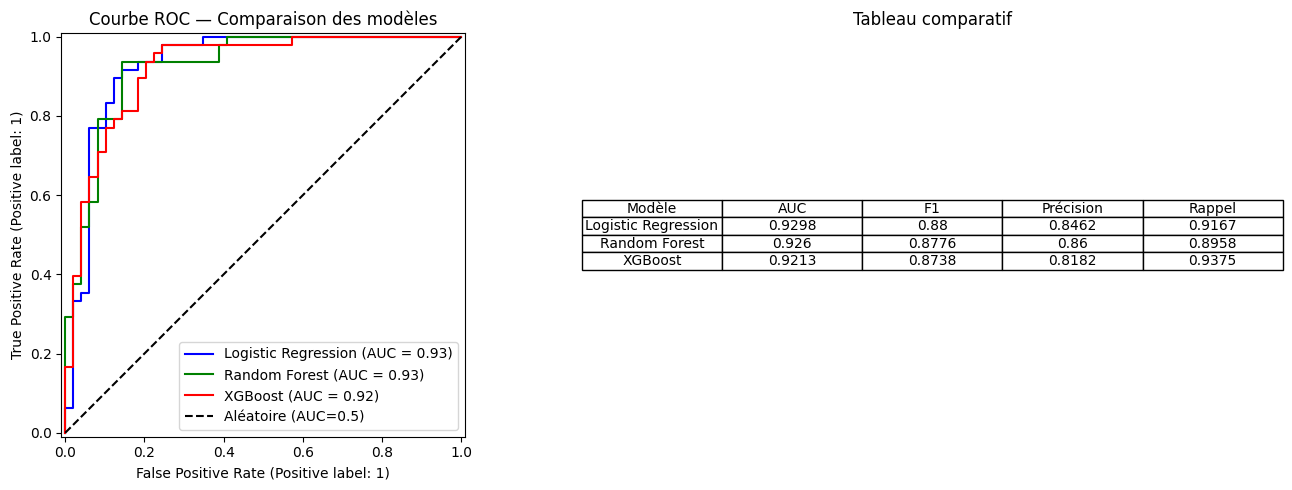

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe ROC pour chaque modèle
for nom, modele, couleur in [
    ("Logistic Regression", log_reg, "blue"),
    ("Random Forest", rf_clf, "green"),
    ("XGBoost", xgb_clf, "red")
]:
    RocCurveDisplay.from_estimator(
        modele, X_test_s, y_test_s,
        ax=axes[0], name=nom, color=couleur
    )

axes[0].plot([0,1],[0,1],'k--', label='Aléatoire (AUC=0.5)')
axes[0].set_title("Courbe ROC — Comparaison des modèles")
axes[0].legend()

# Tableau des scores
df_scoring = pd.DataFrame(resultats_scoring)
axes[1].axis('off')
table = axes[1].table(
    cellText=df_scoring.values,
    colLabels=df_scoring.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
axes[1].set_title("Tableau comparatif")

plt.tight_layout()
plt.show()

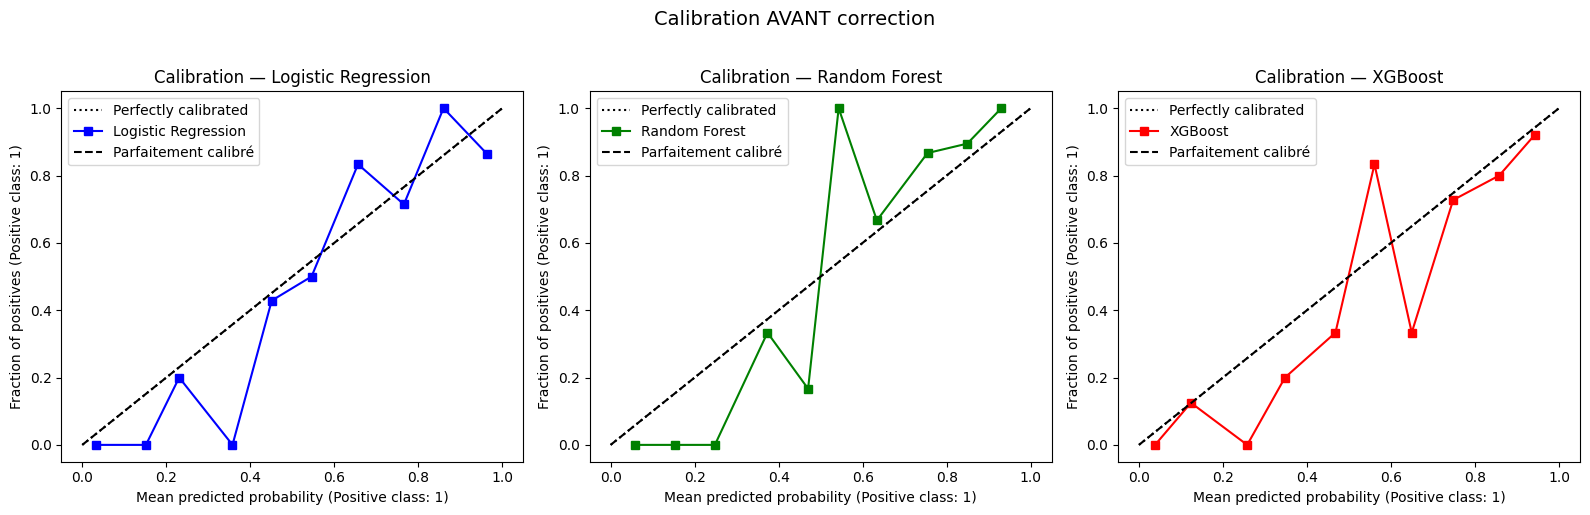

In [60]:
# Visualiser avant  calibration
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

modeles_scoring = [
    ("Logistic Regression", log_reg),
    ("Random Forest",       rf_clf),
    ("XGBoost",             xgb_clf)
]

for idx, (nom, modele) in enumerate(modeles_scoring):
    CalibrationDisplay.from_estimator(
        modele,
        X_test_s,
        y_test_s,
        n_bins   = 10,
        ax       = axes[idx],
        name     = nom,
        color    = ['blue', 'green', 'red'][idx]
    )
    axes[idx].set_title(f"Calibration — {nom}")
    axes[idx].plot([0,1],[0,1],'k--', label='Parfaitement calibré')
    axes[idx].legend()

plt.suptitle("Calibration AVANT correction", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [61]:
# Deux méthodes de calibration :
# ─────────────────────────────────────────────────────
# Platt Scaling (sigmoid) → pour les modèles linéaires
# Isotonic Regression     → pour les modèles non-linéaires
#                           (plus flexible mais besoin de + de données)

# On calibre les 3 modèles
cal_log = CalibratedClassifierCV(log_reg, cv=5, method='sigmoid')
cal_rf  = CalibratedClassifierCV(rf_clf,  cv=5, method='isotonic')
cal_xgb = CalibratedClassifierCV(xgb_clf, cv=5, method='isotonic')

cal_log.fit(X_train_s, y_train_s)
cal_rf.fit(X_train_s,  y_train_s)
cal_xgb.fit(X_train_s, y_train_s)

print("✅ Calibration appliquée sur les 3 modèles")

✅ Calibration appliquée sur les 3 modèles


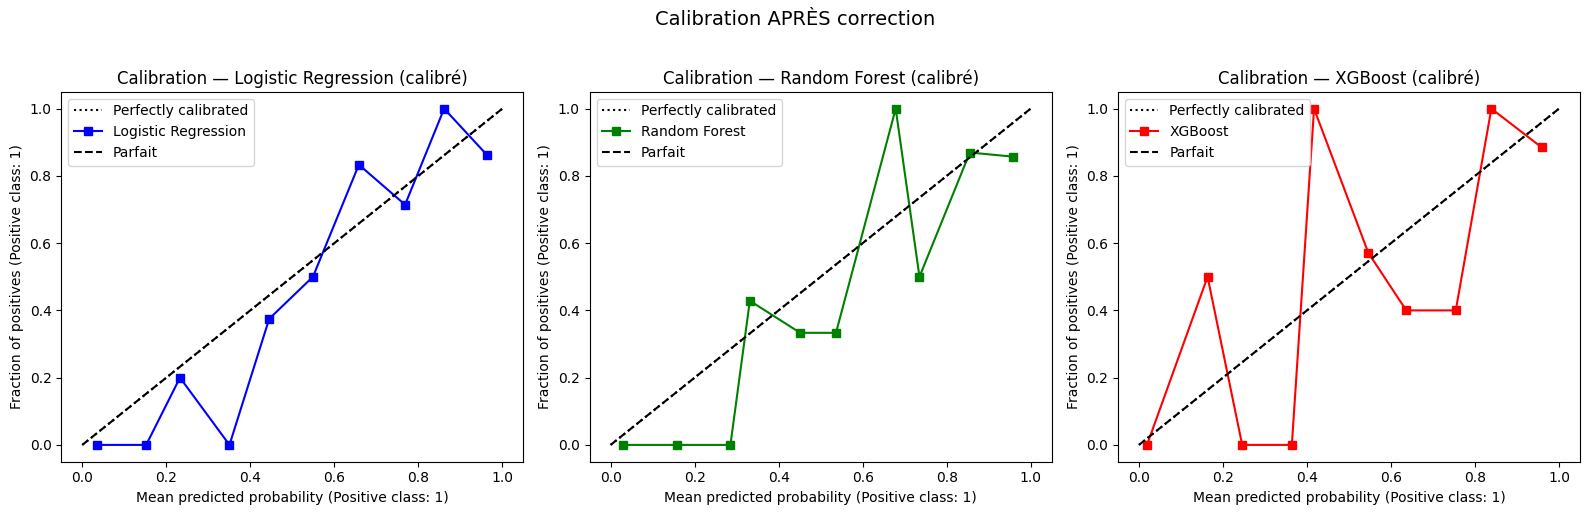

In [62]:
# Visualiser APRÈS calibration
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

modeles_calibres = [
    ("Logistic Regression", cal_log, 'blue'),
    ("Random Forest",       cal_rf,  'green'),
    ("XGBoost",             cal_xgb, 'red')
]

for idx, (nom, modele, couleur) in enumerate(modeles_calibres):
    CalibrationDisplay.from_estimator(
        modele,
        X_test_s,
        y_test_s,
        n_bins = 10,
        ax     = axes[idx],
        name   = nom,
        color  = couleur
    )
    axes[idx].plot([0,1],[0,1],'k--', label='Parfait')
    axes[idx].set_title(f"Calibration — {nom} (calibré)")
    axes[idx].legend()

plt.suptitle("Calibration APRÈS correction", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [63]:
print("📊 Scores AVANT vs APRÈS calibration\n")
print(f"{'Modèle':<25} {'AUC avant':>10} {'AUC après':>10} {'Diff':>8}")
print("━" * 58)

for (nom, avant), (_, apres, _) in zip(modeles_scoring, modeles_calibres):
    auc_avant = roc_auc_score(y_test_s, avant.predict_proba(X_test_s)[:,1])
    auc_apres = roc_auc_score(y_test_s, apres.predict_proba(X_test_s)[:,1])
    diff = auc_apres - auc_avant
    signe = "+" if diff >= 0 else ""
    print(f"{nom:<25} {auc_avant:>10.4f} {auc_apres:>10.4f} {signe}{diff:>7.4f}")

📊 Scores AVANT vs APRÈS calibration

Modèle                     AUC avant  AUC après     Diff
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Logistic Regression           0.9298     0.9298 -0.0000
Random Forest                 0.9260     0.9124 -0.0136
XGBoost                       0.9213     0.9277 + 0.0064



> ```
> En général la calibration ne dégrade pas l'AUC
> Elle ajuste juste les probabilités pour qu'elles soient fiables
> AUC mesure le classement, pas les probabilités elles-mêmes
> ```


# 🔍 SHAP — Expliquer les décisions du modèle

## C'est quoi SHAP ?
```
Le modèle prédit : "Cette voiture a 87% de chances d'être chère"

SHAP répond à la question :
"Pourquoi 87% ? Quelle variable a contribué à ce score ?"

puissance_cv = 320cv  →  +35%  ← pousse vers "cher"
kilometrage  = 8 000  →  +28%  ← pousse vers "cher"  
etat         = Mauvais → -18%  ← pousse vers "bon prix"
age          = 1 an    →  +12%  ← pousse vers "cher"
────────────────────────────────
Base (médiane)          = 50%
Total                   = 107% → normalisé à 87%

In [64]:
# On utilise XGBoost car SHAP est nativement intégré dans XGBoost
# (TreeExplainer est le plus rapide pour les arbres)

explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_test_s)

print(f"✅ SHAP calculé")
print(f"Shape des valeurs SHAP : {shap_values.shape}")
# → (97 lignes de test, nb de features)

✅ SHAP calculé
Shape des valeurs SHAP : (97, 18)


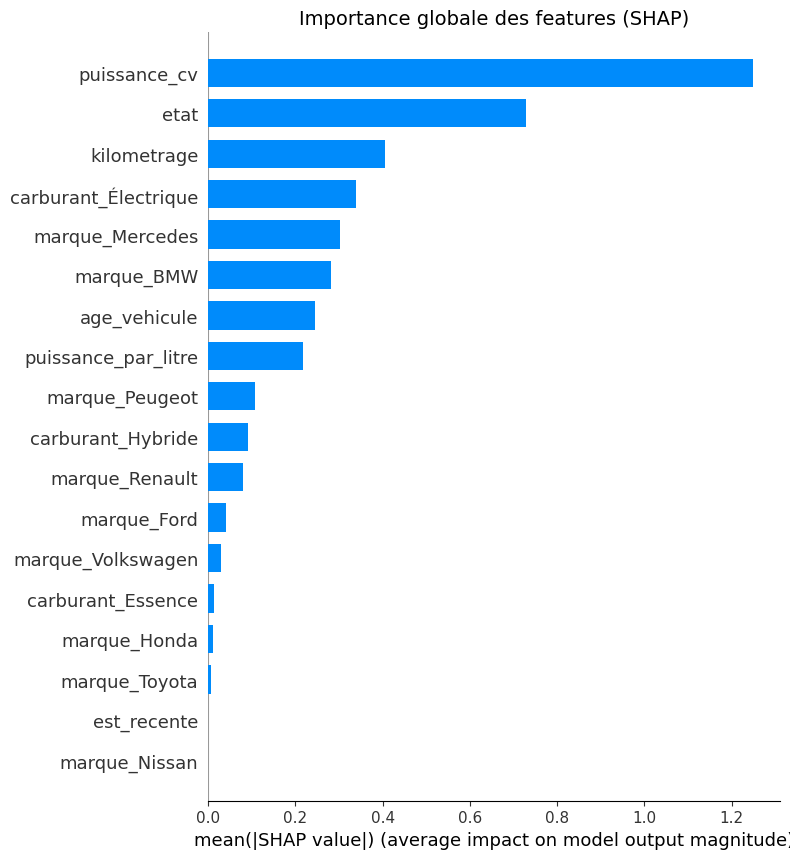

In [65]:
# Summary plot — importance moyenne de chaque feature
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test_s,
    plot_type = "bar",    # barres = importance moyenne
    show      = False
)
plt.title("Importance globale des features (SHAP)", fontsize=14)
plt.tight_layout()
plt.show()

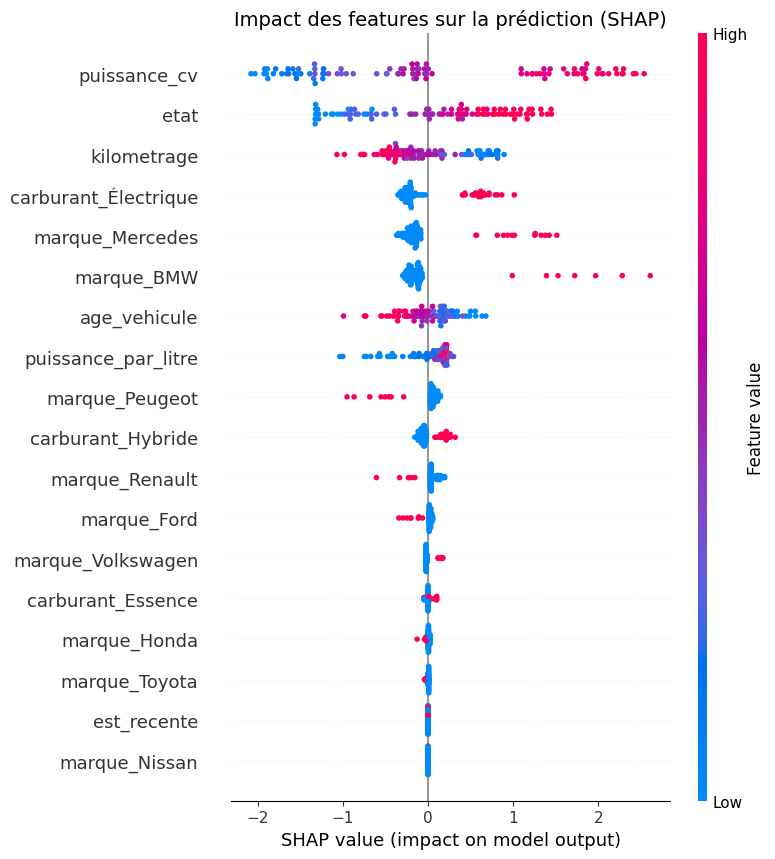

In [66]:
# Dot plot — montre comment chaque feature pousse vers 0 ou 1
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test_s,
    show = False
)
plt.title("Impact des features sur la prédiction (SHAP)", fontsize=14)
plt.tight_layout()
plt.show()

Chaque point = une voiture du test

Position horizontale = valeur SHAP
  → droite (rouge) = pousse vers "CHER"
  → gauche (bleu)  = pousse vers "BON PRIX"

Couleur du point = valeur de la feature
  → rouge = valeur élevée de la variable
  → bleu  = valeur faible de la variable

Exemple sur puissance_cv :
  points rouges à droite → haute puissance = pousse vers "cher" ✅
  points bleus à gauche  → faible puissance = pousse vers "bon prix" ✅

🚗 Voiture analysée (index 0) :
kilometrage            -0.984285
puissance_cv            0.874214
etat                    0.333333
marque_BMW                  True
marque_Ford                False
marque_Honda               False
marque_Mercedes            False
marque_Nissan              False
marque_Peugeot             False
marque_Renault             False
marque_Toyota              False
marque_Volkswagen          False
carburant_Essence          False
carburant_Hybride          False
carburant_Électrique       False
age_vehicule                -0.9
puissance_par_litre     0.353365
est_recente                    1
Name: 382, dtype: object

🎯 Probabilité prédite d'être chère : 97.7%
🏷️  Classe réelle : Chère


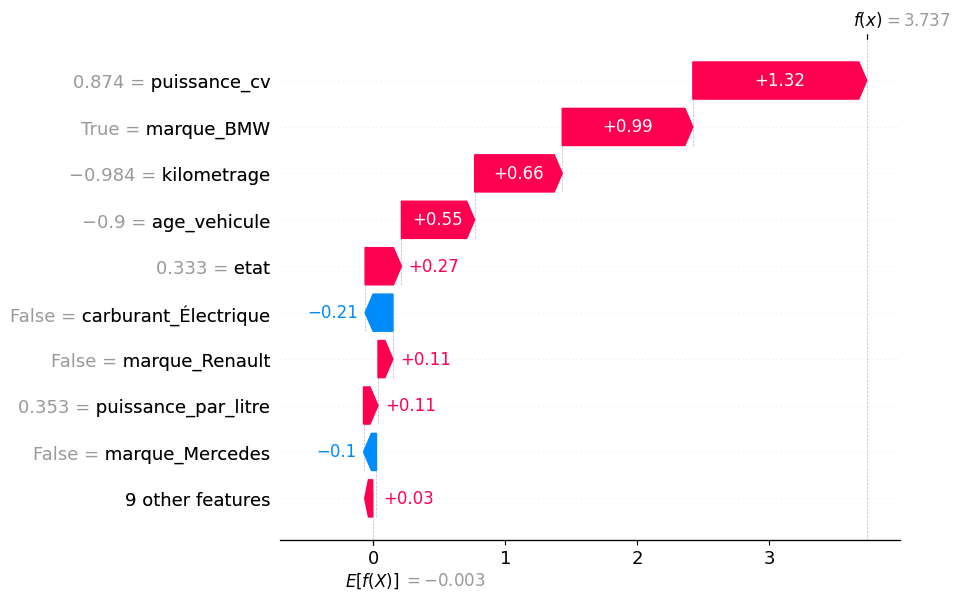

In [67]:
# On explique la prédiction pour la 1ère voiture du test
idx_voiture = 0

print(f"🚗 Voiture analysée (index {idx_voiture}) :")
print(X_test_s.iloc[idx_voiture])
print(f"\n🎯 Probabilité prédite d'être chère : \
{xgb_clf.predict_proba(X_test_s)[idx_voiture, 1]:.1%}")
print(f"🏷️  Classe réelle : \
{'Chère' if y_test_s.iloc[idx_voiture]==1 else 'Bon prix'}")

# Waterfall plot — explication visuelle de cette voiture
shap.plots.waterfall(
    shap.Explanation(
        values        = shap_values[idx_voiture],
        base_values   = explainer.expected_value,
        data          = X_test_s.iloc[idx_voiture],
        feature_names = X_test_s.columns.tolist()
    )
)

PHASE 1 — EDA
✅ Statistiques descriptives
✅ Détection valeurs manquantes (heatmap)
✅ Distribution de la target (skewness)
✅ Matrice de corrélation

PHASE 2 — NETTOYAGE
✅ Suppression doublons        (15 supprimés)
✅ Correction des types        (annee string → int)
✅ Suppression outliers IQR    (17 supprimés)
✅ Imputation médiane/mode     (valeurs manquantes)
✅ Encodage                    (Ordinal, Label, OneHot)
✅ Feature Engineering         (3 nouvelles features)
✅ Suppression features nulles (4 supprimées)
✅ Normalisation RobustScaler

PHASE 3 — MODÉLISATION RÉGRESSION
✅ LinearRegression            R²=0.68  🥇
✅ Ridge / Lasso / ElasticNet
✅ Decision Tree
✅ Random Forest               overfit corrigé
✅ XGBoost                     overfit corrigé
✅ KNN Regressor

PHASE 4 — TUNING
✅ RandomizedSearchCV
✅ Cross-Validation 5 folds
✅ Comparaison avant/après

PHASE 5 — SCORING
✅ Création variable binaire
✅ Logistic Regression         AUC=0.93  🥇
✅ Random Forest Classifier
✅ XGBoost Classifier
✅ Courbe ROC
✅ Précision / Rappel / F1

PHASE 6 — CALIBRATION & EXPLICABILITÉ
✅ CalibrationDisplay avant/après
✅ CalibratedClassifierCV
✅ SHAP global (summary plot)
✅ SHAP individuel (waterfall)

SOUS PIPELINE ET RECOMMANDER

In [68]:
# On recharge le dataset original SANS aucun preprocessing
# pour tout refaire proprement dans le Pipeline

df_raw = pd.read_csv("cars_dataset.csv")

# Correction du type annee uniquement (c'est une erreur de données)
df_raw['annee'] = df_raw['annee'].astype(float).astype(int)

# Suppression doublons et outliers (ces étapes restent hors Pipeline)
df_raw = df_raw.drop_duplicates().reset_index(drop=True)

Q1 = df_raw['prix'].quantile(0.25)
Q3 = df_raw['prix'].quantile(0.75)
IQR = Q3 - Q1
df_raw = df_raw[
    (df_raw['prix'] >= Q1 - 1.5*IQR) &
    (df_raw['prix'] <= Q3 + 1.5*IQR)
].reset_index(drop=True)

print(f"✅ Dataset brut prêt : {df_raw.shape}")
print(df_raw.dtypes)

✅ Dataset brut prêt : (483, 11)
marque                  object
annee                    int64
kilometrage            float64
puissance_cv           float64
nb_portes                int64
carburant               object
transmission            object
etat                    object
nb_proprietaires       float64
consommation_L100km    float64
prix                     int64
dtype: object


In [69]:
from sklearn.base import BaseEstimator, TransformerMixin

# On crée notre propre étape de pipeline
# BaseEstimator + TransformerMixin = conventions sklearn obligatoires

class FeatureEngineer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self  # rien à apprendre ici

    def transform(self, X):
        X = X.copy()

        # Nos features engineerées
        X['age_vehicule']        = 2024 - X['annee']
        X['km_par_an']           = X['kilometrage'] / (X['age_vehicule'] + 1)
        X['puissance_par_litre'] = X['puissance_cv'] / X['consommation_L100km']
        X['est_recente']         = (X['age_vehicule'] <= 5).astype(int)

        # On supprime annee (remplacée par age_vehicule)
        X = X.drop(columns=['annee'])

        return X

print("✅ FeatureEngineer créé")

✅ FeatureEngineer créé


In [70]:
# On définit qui est quoi AVANT le pipeline
# (sur le dataset brut, avant toute transformation)

# Colonnes numériques à imputer + normaliser
cols_numeriques = [
    'kilometrage', 'puissance_cv', 'consommation_L100km',
    'nb_proprietaires', 'nb_portes',
    'age_vehicule', 'km_par_an', 'puissance_par_litre', 'est_recente'
]

# Colonnes catégorielles nominales → OneHot
cols_onehot = ['marque', 'carburant']

# Colonnes catégorielles ordinales → Ordinal
cols_ordinal = ['etat']

# Colonne binaire → Label
cols_binaire = ['transmission']

print("✅ Colonnes définies")

✅ Colonnes définies


In [71]:
# ── Pipeline pour les numériques ─────────────────────
pipe_numerique = Pipeline([
    ('imputer',    SimpleImputer(strategy='median')),
    ('scaler',     RobustScaler())
])

# ── Pipeline pour les OneHot ──────────────────────────
pipe_onehot = Pipeline([
    ('imputer',  SimpleImputer(strategy='most_frequent')),
    ('encoder',  OneHotEncoder(drop='first', sparse_output=False,
                               handle_unknown='ignore'))
])

# ── Pipeline pour l'ordinal ───────────────────────────
pipe_ordinal = Pipeline([
    ('imputer',  SimpleImputer(strategy='most_frequent')),
    ('encoder',  OrdinalEncoder(
                    categories=[['Mauvais','Passable','Bon','Très bon','Neuf']],
                    handle_unknown='use_encoded_value',
                    unknown_value=-1
                ))
])

# ── Pipeline pour le binaire ──────────────────────────
pipe_binaire = Pipeline([
    ('imputer',  SimpleImputer(strategy='most_frequent')),
    ('encoder',  OrdinalEncoder())  # Manuelle=0 / Automatique=1
])

print("✅ Sous-pipelines créés")

✅ Sous-pipelines créés


In [72]:
# ColumnTransformer = chef d'orchestre
# Il distribue chaque colonne au bon sous-pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('num',     pipe_numerique, cols_numeriques),
        ('onehot',  pipe_onehot,    cols_onehot),
        ('ordinal', pipe_ordinal,   cols_ordinal),
        ('binaire', pipe_binaire,   cols_binaire)
    ],
    remainder='drop'  # on supprime tout ce qu'on a pas listé
)

print("✅ ColumnTransformer créé")

✅ ColumnTransformer créé


In [73]:
# On assemble TOUT en un seul objet
pipeline_lr = Pipeline([
    ('feature_eng',  FeatureEngineer()),   # Step 1 : feature engineering
    ('preprocessor', preprocessor),        # Step 2 : imputation + encodage + scaling
    ('modele',       LinearRegression())   # Step 3 : modèle
])

pipeline_xgb = Pipeline([
    ('feature_eng',  FeatureEngineer()),
    ('preprocessor', preprocessor),
    ('modele',       XGBRegressor(
                        n_estimators=200,
                        learning_rate=0.05,
                        max_depth=4,
                        subsample=0.8,
                        random_state=set_seed,
                        verbosity=0
                    ))
])

print("✅ Pipelines complets créés")

✅ Pipelines complets créés


In [74]:
# On sépare X et y sur le dataset BRUT (sans preprocessing)
X_raw = df_raw.drop(columns=['prix'])
y_raw = df_raw['prix']

# Split d'abord → AUCUNE fuite possible
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_raw, y_raw,
    test_size=0.2,
    random_state=set_seed
)

# Le Pipeline fait tout automatiquement :
# fit()     → apprend imputer + scaler sur X_train UNIQUEMENT
# transform → applique sur X_train
pipeline_lr.fit(X_train_r, y_train_r)
pipeline_xgb.fit(X_train_r, y_train_r)

print("✅ Pipelines entraînés")
print(f"Train : {X_train_r.shape} / Test : {X_test_r.shape}")

✅ Pipelines entraînés
Train : (386, 10) / Test : (97, 10)


In [75]:
for nom, pipe in [("LR Pipeline", pipeline_lr),
                   ("XGB Pipeline", pipeline_xgb)]:
    y_pred = pipe.predict(X_test_r)
    mae    = mean_absolute_error(y_test_r, y_pred)
    r2     = r2_score(y_test_r, y_pred)
    print(f"\n{nom}")
    print(f"  MAE : {mae:,.0f} €")
    print(f"  R²  : {r2:.4f}")


LR Pipeline
  MAE : 4,517 €
  R²  : 0.6794

XGB Pipeline
  MAE : 5,851 €
  R²  : 0.5616


In [76]:
# C'est là que le Pipeline devient MAGIQUE
# On donne une voiture brute → on obtient un prix directement

nouvelle_voiture = pd.DataFrame([
    {
        'marque'              : 'BMW',
        'annee'               : 2020,
        'kilometrage'         : 45000,
        'puissance_cv'        : 190,
        'nb_portes'           : 4,
        'carburant'           : 'Essence',
        'transmission'        : 'Automatique',
        'etat'                : 'Très bon',
        'nb_proprietaires'    : 2,
        'consommation_L100km' : 7.2
    }
])

prix_predit = pipeline_lr.predict(nouvelle_voiture)[0]
print(f"🚗 BMW 2020, 45 000km, 190cv, Très bon état")
print(f"💰 Prix prédit : {prix_predit:,.0f} €")

🚗 BMW 2020, 45 000km, 190cv, Très bon état
💰 Prix prédit : 39,447 €


In [77]:
import joblib

# ── Sauvegarder ──────────────────────────────────────
joblib.dump(pipeline_lr, 'pipeline_voiture.joblib')
print("✅ Pipeline sauvegardé avec joblib")



✅ Pipeline sauvegardé avec joblib


In [78]:
# ── Recharger ─────────────────────────────────────────
pipeline_charge = joblib.load('pipeline_voiture.joblib')
prix = pipeline_charge.predict(nouvelle_voiture)[0]
print(f"💰 Prix prédit : {prix:,.0f} €")

💰 Prix prédit : 39,447 €


In [79]:
# Pour accéder à un paramètre dans le pipeline on utilise :
# 'nom_etape__nom_parametre'  (double underscore)

# Exemples :
# 'modele__max_depth'              → max_depth du modèle
# 'preprocessor__num__scaler'      → scaler des numériques
# 'feature_eng__...'               → paramètre du feature engineer

print("Tous les paramètres disponibles dans le pipeline :")
print(pipeline_xgb.get_params().keys())

Tous les paramètres disponibles dans le pipeline :
dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'feature_eng', 'preprocessor', 'modele', 'preprocessor__force_int_remainder_cols', 'preprocessor__n_jobs', 'preprocessor__remainder', 'preprocessor__sparse_threshold', 'preprocessor__transformer_weights', 'preprocessor__transformers', 'preprocessor__verbose', 'preprocessor__verbose_feature_names_out', 'preprocessor__num', 'preprocessor__onehot', 'preprocessor__ordinal', 'preprocessor__binaire', 'preprocessor__num__memory', 'preprocessor__num__steps', 'preprocessor__num__transform_input', 'preprocessor__num__verbose', 'preprocessor__num__imputer', 'preprocessor__num__scaler', 'preprocessor__num__imputer__add_indicator', 'preprocessor__num__imputer__copy', 'preprocessor__num__imputer__fill_value', 'preprocessor__num__imputer__keep_empty_features', 'preprocessor__num__imputer__missing_values', 'preprocessor__num__imputer__strategy', 'preprocessor__num__scaler__copy', 'preprocesso

In [80]:
param_grid_xgb = {
    # Paramètres du MODÈLE
    'modele__n_estimators'    : [50, 100, 200, 300],
    'modele__max_depth'       : [2, 3, 4, 5],
    'modele__learning_rate'   : [0.01, 0.05, 0.1],
    'modele__subsample'       : [0.6, 0.7, 0.8],
    'modele__colsample_bytree': [0.6, 0.7, 0.8],
    'modele__reg_alpha'       : [0, 0.1, 1, 5],
    'modele__reg_lambda'      : [1, 5, 10]
}

search_pipe_xgb = RandomizedSearchCV(
    estimator            = pipeline_xgb,
    param_distributions  = param_grid_xgb,
    n_iter               = 30,
    cv                   = 5,
    scoring              = 'r2',
    n_jobs               = -1,
    random_state         = set_seed,
    verbose              = 1
)

search_pipe_xgb.fit(X_train_r, y_train_r)

print(f"\n✅ Meilleurs paramètres :")
print(search_pipe_xgb.best_params_)
print(f"\n✅ Meilleur R² en CV : {search_pipe_xgb.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Meilleurs paramètres :
{'modele__subsample': 0.7, 'modele__reg_lambda': 5, 'modele__reg_alpha': 5, 'modele__n_estimators': 300, 'modele__max_depth': 2, 'modele__learning_rate': 0.05, 'modele__colsample_bytree': 0.7}

✅ Meilleur R² en CV : 0.6867


In [81]:
# Pour la régression linéaire on teste Ridge et Lasso
# en changeant directement le modèle dans le pipeline

from sklearn.pipeline import Pipeline

param_grid_lr = {
    # On teste 3 modèles différents directement
    'modele'              : [
        LinearRegression(),
        Ridge(alpha=1),
        Ridge(alpha=10),
        Ridge(alpha=100),
        Lasso(alpha=1),
        Lasso(alpha=10)
    ]
}

search_pipe_lr = GridSearchCV(
    estimator   = pipeline_lr,
    param_grid  = param_grid_lr,
    cv          = 5,
    scoring     = 'r2',
    n_jobs      = -1,
    verbose     = 1
)

search_pipe_lr.fit(X_train_r, y_train_r)

print(f"\n✅ Meilleur modèle linéaire :")
print(search_pipe_lr.best_params_)
print(f"✅ Meilleur R² en CV : {search_pipe_lr.best_score_:.4f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits

✅ Meilleur modèle linéaire :
{'modele': Ridge(alpha=1)}
✅ Meilleur R² en CV : 0.7299


In [82]:
# On récupère les meilleurs pipelines
best_pipe_xgb = search_pipe_xgb.best_estimator_
best_pipe_lr  = search_pipe_lr.best_estimator_

print("\n🏆 RÉSULTATS FINAUX AVEC PIPELINE")
print("━" * 50)

for nom, pipe in [("LR  (Pipeline tuné)",  best_pipe_lr),
                   ("XGB (Pipeline tuné)", best_pipe_xgb)]:

    y_pred_train = pipe.predict(X_train_r)
    y_pred_test  = pipe.predict(X_test_r)

    mae      = mean_absolute_error(y_test_r,  y_pred_test)
    rmse     = np.sqrt(mean_squared_error(y_test_r, y_pred_test))
    r2_test  = r2_score(y_test_r,  y_pred_test)
    r2_train = r2_score(y_train_r, y_pred_train)

    print(f"\n  📊 {nom}")
    print(f"  MAE      : {mae:>10,.0f} €")
    print(f"  RMSE     : {rmse:>10,.0f} €")
    print(f"  R² Test  : {r2_test:>10.4f}")
    print(f"  R² Train : {r2_train:>10.4f}")
    print(f"  Overfit  : {r2_train - r2_test:>10.4f}")


🏆 RÉSULTATS FINAUX AVEC PIPELINE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  📊 LR  (Pipeline tuné)
  MAE      :      4,595 €
  RMSE     :      7,627 €
  R² Test  :     0.6758
  R² Train :     0.7607
  Overfit  :     0.0849

  📊 XGB (Pipeline tuné)
  MAE      :      5,889 €
  RMSE     :      8,742 €
  R² Test  :     0.5740
  R² Train :     0.8237
  Overfit  :     0.2497


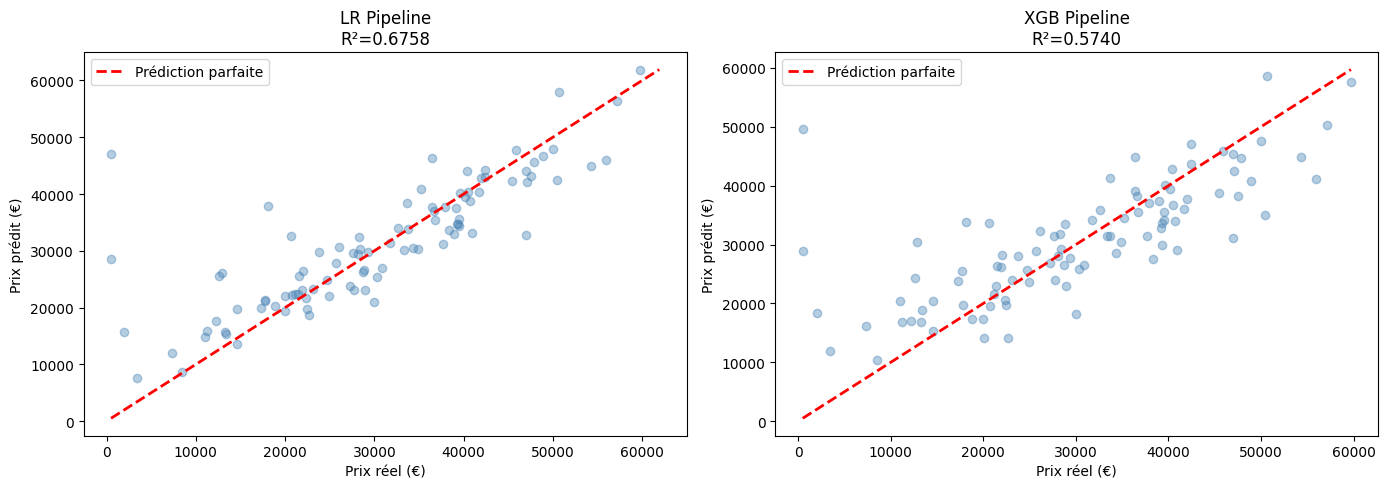

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (nom, pipe) in enumerate([
    ("LR Pipeline",  best_pipe_lr),
    ("XGB Pipeline", best_pipe_xgb)
]):
    y_pred = pipe.predict(X_test_r)

    # Scatter plot réel vs prédit
    axes[idx].scatter(y_test_r, y_pred, alpha=0.4, color='steelblue')

    # Ligne parfaite (si prédit = réel)
    min_val = min(y_test_r.min(), y_pred.min())
    max_val = max(y_test_r.max(), y_pred.max())
    axes[idx].plot([min_val, max_val], [min_val, max_val],
                    'r--', linewidth=2, label='Prédiction parfaite')

    axes[idx].set_xlabel("Prix réel (€)")
    axes[idx].set_ylabel("Prix prédit (€)")
    axes[idx].set_title(f"{nom}\nR²={r2_score(y_test_r, y_pred):.4f}")
    axes[idx].legend()

plt.tight_layout()
plt.show()

In [84]:
import joblib

# Sauvegarde des deux meilleurs pipelines
joblib.dump(best_pipe_lr,  'best_pipeline_lr.joblib')
joblib.dump(best_pipe_xgb, 'best_pipeline_xgb.joblib', compress=3)

print("✅ Pipelines sauvegardés")

# ── Test en production ────────────────────────────────
# On simule 3 nouvelles voitures à pricer

nouvelles_voitures = pd.DataFrame([
    {
        'marque': 'BMW', 'annee': 2020, 'kilometrage': 45000,
        'puissance_cv': 190, 'nb_portes': 4, 'carburant': 'Essence',
        'transmission': 'Automatique', 'etat': 'Très bon',
        'nb_proprietaires': 1, 'consommation_L100km': 7.2
    },
    {
        'marque': 'Renault', 'annee': 2015, 'kilometrage': 120000,
        'puissance_cv': 90, 'nb_portes': 5, 'carburant': 'Diesel',
        'transmission': 'Manuelle', 'etat': 'Bon',
        'nb_proprietaires': 2, 'consommation_L100km': 5.5
    },
    {
        'marque': 'Mercedes', 'annee': 2022, 'kilometrage': 15000,
        'puissance_cv': 300, 'nb_portes': 4, 'carburant': 'Hybride',
        'transmission': 'Automatique', 'etat': 'Neuf',
        'nb_proprietaires': 1, 'consommation_L100km': 6.8
    }
])

print("\n🚗 PRÉDICTIONS EN PRODUCTION")
print("━" * 55)

prix_lr  = best_pipe_lr.predict(nouvelles_voitures)
prix_xgb = best_pipe_xgb.predict(nouvelles_voitures)

descriptions = [
    "BMW 2020, 45 000km, 190cv",
    "Renault 2015, 120 000km, 90cv",
    "Mercedes 2022, 15 000km, 300cv"
]

for desc, p_lr, p_xgb in zip(descriptions, prix_lr, prix_xgb):
    print(f"\n  🚘 {desc}")
    print(f"     LR  → {p_lr:>10,.0f} €")
    print(f"     XGB → {p_xgb:>10,.0f} €")
    print(f"     Écart → {abs(p_lr - p_xgb):>8,.0f} €")

✅ Pipelines sauvegardés

🚗 PRÉDICTIONS EN PRODUCTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  🚘 BMW 2020, 45 000km, 190cv
     LR  →     39,278 €
     XGB →     39,442 €
     Écart →      163 €

  🚘 Renault 2015, 120 000km, 90cv
     LR  →     13,407 €
     XGB →     16,309 €
     Écart →    2,901 €

  🚘 Mercedes 2022, 15 000km, 300cv
     LR  →     60,192 €
     XGB →     56,573 €
     Écart →    3,619 €
